✔ Étape 1 : Toutes les bibliothèques ont été importées avec succès !

Chargement des données depuis l'URL : https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv ...

--- Aperçu des 5 premières lignes du dataset ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dimensions du dataset (lignes, colonnes) : (150, 5)

Noms des variables : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Types de données de chaque colonne :
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- Analyse exploratoire ---

Statistiques descriptives des v

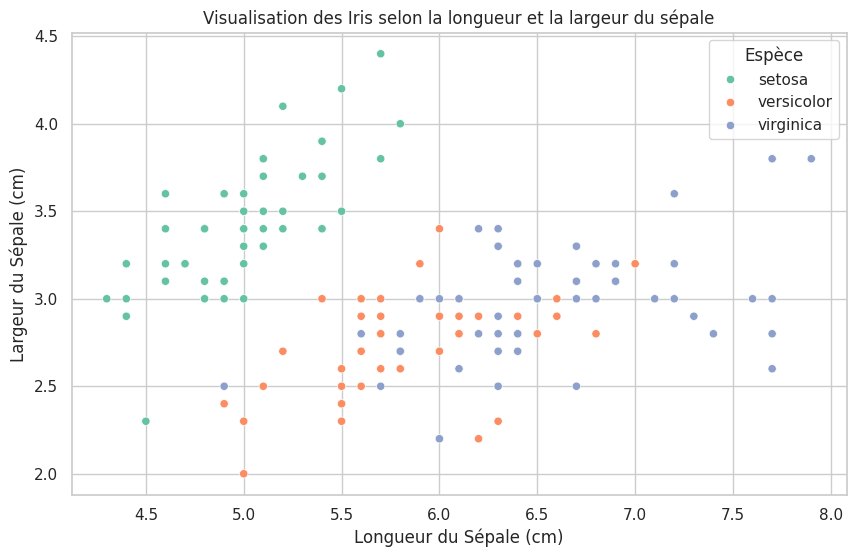


--- Définition des variables du modèle ---
Variables explicatives (X) : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Variable à prédire (y) : species (Espèces d'iris)

--- Séparation des données ---
Taille de l'ensemble d'entraînement (X_train) : 120 échantillons
Taille de l'ensemble de test (X_test) : 30 échantillons

✔ Étape 6 : Les données ont été normalisées avec succès.

✔ Étape 7 : Le modèle d'Arbre de Décision a été entraîné avec succès sur l'ensemble d'entraînement.

--- Comparaison des 5 premières prédictions sur l'ensemble de test ---
  Valeur Réelle Valeur Prédite
0    versicolor     versicolor
1        setosa         setosa
2     virginica      virginica
3    versicolor     versicolor
4    versicolor     versicolor

--- Évaluation des performances du modèle ---
Précision globale du modèle (Accuracy) : 1.00 (100.0%)

Rapport de classification détaillé :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00      

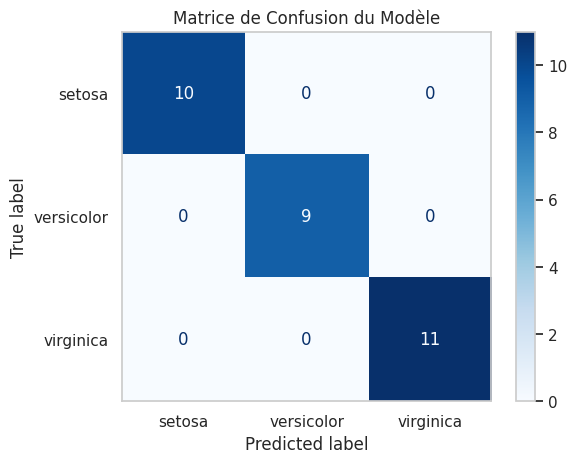


--- Validation Croisée (5 plis) ---
Scores obtenus à chaque étape : [0.96666667 0.96666667 0.93333333 1.         1.        ]
Précision moyenne globale : 97.33% (+/- 2.49%)

--- Nouvelle observation à prédire ---
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

🚀 Prédiction du modèle : setosa
Probabilités associées pour chaque classe :
 - setosa : 100.0%
 - versicolor : 0.0%
 - virginica : 0.0%

Interprétation : Le modèle estime avec une probabilité maximale qu'il s'agit d'une iris de l'espèce 'setosa'.


In [1]:
# ==============================================================================
# PROJET PEDAGOGIQUE : CLASSIFICATION DE FLEURS D'IRIS (MACHINE LEARNING)
# ==============================================================================

# ------------------------------------------------------------------------------
# Étape 1 : Importation des bibliothèques nécessaires
# ------------------------------------------------------------------------------
# Nous importons les outils standards pour manipuler les données, les visualiser
# et construire notre modèle prédictif.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Outils de préparation de données et d'évaluation avec scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuration de la visualisation
sns.set_theme(style="whitegrid")

print("✔ Étape 1 : Toutes les bibliothèques ont été importées avec succès !\n")

# ------------------------------------------------------------------------------
# Étape 2 : Chargement des données à partir d'une URL publique
# ------------------------------------------------------------------------------
# Nous utilisons l'URL brute du jeu de données Iris disponible sur le dépôt GitHub officiel d'UCI / pandas.
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
print(f"Chargement des données depuis l'URL : {url} ...")
df = pd.read_csv(url)

# Affichage des premières lignes pour vérifier l'intégrité du chargement
print("\n--- Aperçu des 5 premières lignes du dataset ---")
print(df.head())

# Dimensions du dataset
print(f"\nDimensions du dataset (lignes, colonnes) : {df.shape}")

# Noms des variables (colonnes)
print("\nNoms des variables :", list(df.columns))

# Types de données de chaque colonne
print("\nTypes de données de chaque colonne :")
print(df.dtypes)

# ------------------------------------------------------------------------------
# Étape 3 : Analyse exploratoire des données
# ------------------------------------------------------------------------------
print("\n--- Analyse exploratoire ---")

# 1. Statistiques descriptives globales
print("\nStatistiques descriptives des variables numériques :")
print(df.describe())

# 2. Vérification des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 3. Distribution de la variable cible (les espèces d'iris)
print("\nDistribution de la variable cible ('species') :")
print(df['species'].value_counts())

# 4. Visualisation simple : Nuage de points interactif (ou tracé de paires)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set2')
plt.title("Visualisation des Iris selon la longueur et la largeur du sépale")
plt.xlabel("Longueur du Sépale (cm)")
plt.ylabel("Largeur du Sépale (cm)")
plt.legend(title='Espèce')
plt.show()

# ------------------------------------------------------------------------------
# Étape 4 : Définition des caractéristiques (X) et de la cible (y)
# ------------------------------------------------------------------------------
# - Les caractéristiques (Features / X) sont les dimensions physiques mesurées.
# - La variable cible (Target / y) est l'espèce que le modèle doit apprendre à prédire.

X = df.drop(columns=['species'])
y = df['species']

print("\n--- Définition des variables du modèle ---")
print(f"Variables explicatives (X) : {list(X.columns)}")
print(f"Variable à prédire (y) : {y.name} (Espèces d'iris)")

# ------------------------------------------------------------------------------
# Étape 5 : Séparation des données en ensembles d'entraînement et de test
# ------------------------------------------------------------------------------
# - L'ensemble d'entraînement (80%) permet d'ajuster les paramètres du modèle.
# - L'ensemble de test (20%) reste secret et permet d'évaluer le modèle sur des données non vues.
# - 'random_state=42' garantit la reproductibilité parfaite des résultats à chaque exécution.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n--- Séparation des données ---")
print(f"Taille de l'ensemble d'entraînement (X_train) : {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test (X_test) : {X_test.shape[0]} échantillons")

# ------------------------------------------------------------------------------
# Étape 6 : Normalisation / Standardisation des données
# ------------------------------------------------------------------------------
# Même si l'arbre de décision n'est pas sensible à l'échelle des données,
# appliquer un StandardScaler est une bonne pratique d'ingénierie des données.
scaler = StandardScaler()

# On ajuste le scaler UNIQUEMENT sur l'ensemble d'entraînement et on transforme les deux ensembles.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✔ Étape 6 : Les données ont été normalisées avec succès.")

# ------------------------------------------------------------------------------
# Étape 7 : Choix et entraînement de l'algorithme (Modèle)
# ------------------------------------------------------------------------------
# Nous choisissons un Arbre de Décision (Decision Tree Classifier).
# Pourquoi ? C'est un algorithme simple, très visuel et parfaitement adapté pour
# séparer des données basées sur des critères de seuils de manière intuitive.

model = DecisionTreeClassifier(random_state=42, max_depth=3)

# Entraînement du modèle
model.fit(X_train_scaled, y_train)
print("\n✔ Étape 7 : Le modèle d'Arbre de Décision a été entraîné avec succès sur l'ensemble d'entraînement.")

# ------------------------------------------------------------------------------
# Étape 8 : Prédictions sur l'ensemble de test
# ------------------------------------------------------------------------------
y_pred = model.predict(X_test_scaled)

# Affichage de quelques valeurs réelles vs valeurs prédites
comparaison_df = pd.DataFrame({
    'Valeur Réelle': y_test.values,
    'Valeur Prédite': y_pred
})
print("\n--- Comparaison des 5 premières prédictions sur l'ensemble de test ---")
print(comparaison_df.head())

# ------------------------------------------------------------------------------
# Étape 9 : Évaluation du modèle
# ------------------------------------------------------------------------------
print("\n--- Évaluation des performances du modèle ---")

# Calcul de la précision globale (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision globale du modèle (Accuracy) : {accuracy:.2f} ({accuracy * 100:.1f}%)")

# Affichage du rapport complet (Precision, Recall, F1-Score)
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

# Matrice de confusion pour identifier d'éventuelles erreurs de ciblage
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion brute :")
print(cm)

# Visualisation de la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Matrice de Confusion du Modèle")
plt.grid(False)
plt.show()

# ------------------------------------------------------------------------------
# Étape 10 : Validation croisée (Cross-Validation)
# ------------------------------------------------------------------------------
# Pour s'assurer que notre modèle est robuste et qu'il ne dépend pas du hasard du découpage initial,
# nous réalisons une validation croisée à 5 plis (K-Fold).

# On applique la validation croisée sur l'ensemble des données d'origine mises à l'échelle
X_scaled = scaler.fit_transform(X)
scores = cross_val_score(model, X_scaled, y, cv=5)

print("\n--- Validation Croisée (5 plis) ---")
print(f"Scores obtenus à chaque étape : {scores}")
print(f"Précision moyenne globale : {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")

# ------------------------------------------------------------------------------
# Étape 11 : Utilisation pratique du modèle sur une nouvelle donnée
# ------------------------------------------------------------------------------
# Imaginons que nous trouvons une nouvelle fleur d'Iris dans la nature avec les mesures suivantes :
# - sepal_length = 5.1 cm
# - sepal_width = 3.5 cm
# - petal_length = 1.4 cm
# - petal_width = 0.2 cm

nouvelle_donnee = pd.DataFrame({
    "sepal_length": [5.1],
    "sepal_width": [3.5],
    "petal_length": [1.4],
    "petal_width": [0.2]
})

print("\n--- Nouvelle observation à prédire ---")
print(nouvelle_donnee)

# ATTENTION : Il faut obligatoirement appliquer la même normalisation sur la nouvelle donnée !
nouvelle_donnee_scaled = scaler.transform(nouvelle_donnee)

# Prédiction de la classe de la nouvelle fleur
prediction = model.predict(nouvelle_donnee_scaled)
proba_predictions = model.predict_proba(nouvelle_donnee_scaled)

print(f"\n🚀 Prédiction du modèle : {prediction[0]}")
print("Probabilités associées pour chaque classe :")
for classe, proba in zip(model.classes_, proba_predictions[0]):
    print(f" - {classe} : {proba * 100:.1f}%")

print("\nInterprétation : Le modèle estime avec une probabilité maximale qu'il s'agit d'une iris de l'espèce 'setosa'.")
